[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/yotamc19/Image-processing-project/blob/main/notebooks/milestone3_final.ipynb)

# Milestone 3: Fine-Tuning, Test-Set Evaluation & Inference

Final milestone. Builds on the M2 STN-CRNN:

1. **Fine-tune** the STN-CRNN from the M2 weights at a lower learning rate.
2. **Evaluate on the held-out test split** (final, unbiased numbers — M1/M2
   only reported validation).
3. **Inference pipeline** demo (`src/inference.py`): image → text.

The M2 base checkpoint is regenerated here if absent, then fine-tuned; on a
T4 the full run is ~1.5h (base ~1h + fine-tune ~20m + eval).

## 1. Setup

In [1]:
import os, sys
if not os.path.exists('Image-processing-project'):
    !git clone https://github.com/yotamc19/Image-processing-project.git
%cd Image-processing-project
!pip install -q -r requirements.txt
sys.path.insert(0, '.')

/content/Image-processing-project


In [2]:
# QUICK_TEST=True runs the full M3 pipeline on a small subset (~2 min) to verify wiring.
# Set to False for the real fine-tuning + test evaluation.
QUICK_TEST = False
BASE_CONFIG     = 'configs/smoke_test_m2.yaml' if QUICK_TEST else 'configs/milestone2_stn.yaml'
FINETUNE_CONFIG = 'configs/smoke_test_m3.yaml' if QUICK_TEST else 'configs/milestone3_finetune.yaml'
print(f'Base config:     {BASE_CONFIG}')
print(f'Finetune config: {FINETUNE_CONFIG}')

Base config:     configs/milestone2_stn.yaml
Finetune config: configs/milestone3_finetune.yaml


## 2. STN-CRNN Base (regenerate M2 weights if needed)

Fine-tuning needs the M2 weights as a starting point. If `checkpoints_m2/best_model.pt` already exists (e.g. from a live session), this is skipped;
otherwise the STN-CRNN base is trained first.

No M2 base checkpoint found — training STN-CRNN base first...
Using device: cuda


Generating train split:   0%|          | 0/69190 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/23064 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/23064 [00:00<?, ? examples/s]

Train: 69190 samples
Val: 23064 samples
Model parameters: 8,287,803

Epoch 1/50


...

Train Loss: 0.2110 | Val Loss: 0.3997 | CER: 0.0923 | WER: 0.2141

Epoch 49/50


Validating: 100%|██████████| 361/361 [00:18<00:00, 19.61it/s]


Train Loss: 0.2117 | Val Loss: 0.3976 | CER: 0.0914 | WER: 0.2125
  -> New best CER: 0.0914

Epoch 50/50


Validating: 100%|██████████| 361/361 [00:20<00:00, 18.01it/s]


Train Loss: 0.2109 | Val Loss: 0.3977 | CER: 0.0913 | WER: 0.2128
  -> New best CER: 0.0913

Training complete. Best CER: 0.0913


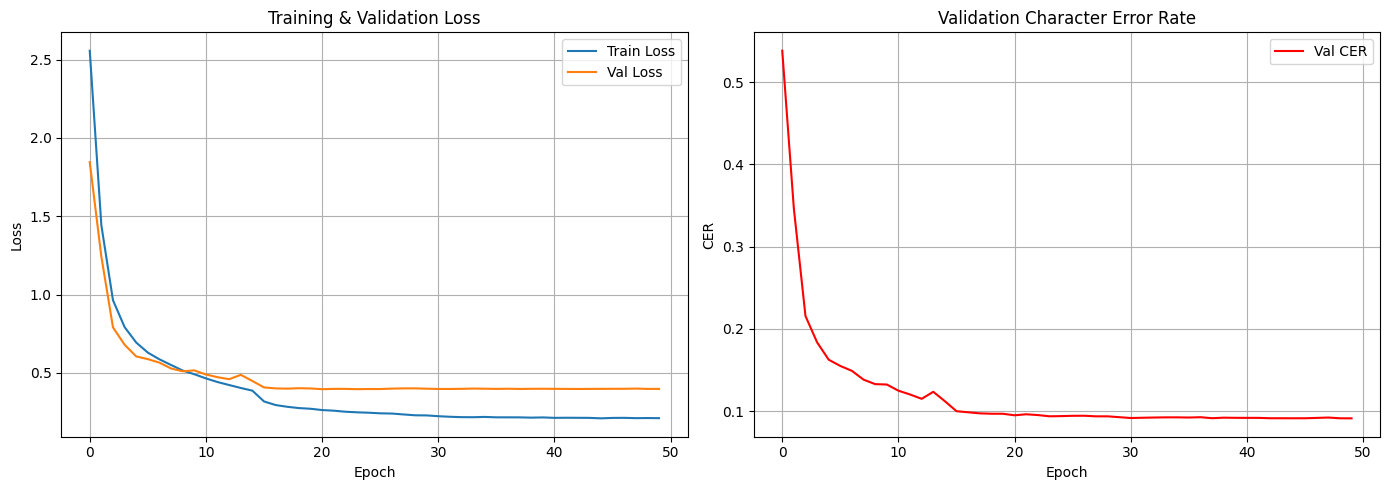

In [3]:
from src.train import train as train_model

if not os.path.exists('checkpoints_m2/best_model.pt'):
    print('No M2 base checkpoint found — training STN-CRNN base first...')
    base_results = train_model(BASE_CONFIG, checkpoint_dir='checkpoints_m2')
else:
    print('Found existing checkpoints_m2/best_model.pt — skipping base training.')
    base_results = None

## 3. Fine-Tune

Continue from the M2 weights at lr 1e-4 (10x lower) for a short schedule.
Early-stops on val CER. Best fine-tuned model saved to `checkpoints_m3/`.

Using device: cuda
Train: 69190 samples
Val: 23064 samples
Model parameters: 8,287,803
Initialized weights from checkpoints_m2/best_model.pt (epoch 49)

Epoch 1/15


Validating: 100%|██████████| 361/361 [00:18<00:00, 19.19it/s]


Train Loss: 0.2173 | Val Loss: 0.4033 | CER: 0.0928 | WER: 0.2158
  -> New best CER: 0.0928

Epoch 2/15


Validating: 100%|██████████| 361/361 [00:19<00:00, 18.78it/s]


Train Loss: 0.2170 | Val Loss: 0.4035 | CER: 0.0929 | WER: 0.2159

Epoch 3/15


...

Train Loss: 0.1961 | Val Loss: 0.4016 | CER: 0.0906 | WER: 0.2105
  -> New best CER: 0.0906

Epoch 14/15


Validating: 100%|██████████| 361/361 [00:18<00:00, 19.33it/s]


Train Loss: 0.1939 | Val Loss: 0.4021 | CER: 0.0903 | WER: 0.2099
  -> New best CER: 0.0903

Epoch 15/15


Validating: 100%|██████████| 361/361 [00:19<00:00, 18.48it/s]


Train Loss: 0.1934 | Val Loss: 0.4016 | CER: 0.0905 | WER: 0.2091

Training complete. Best CER: 0.0903


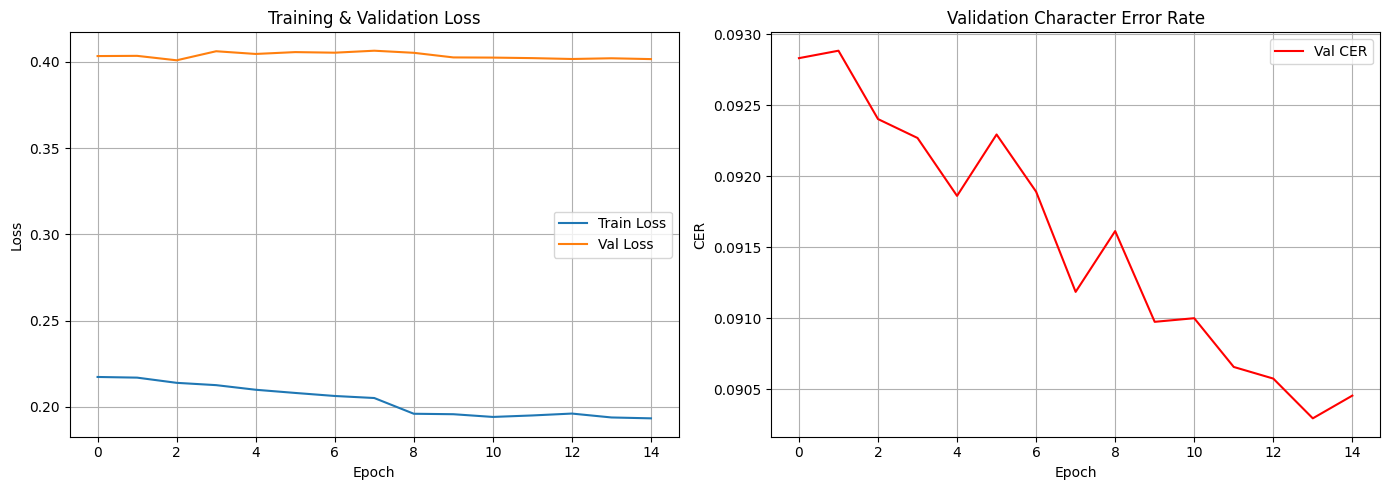

In [4]:
m3_results = train_model(FINETUNE_CONFIG, checkpoint_dir='checkpoints_m3')

## 4. Final Test-Set Evaluation

Score both the pre-fine-tune (M2 base) and fine-tuned (M3) models on the
**test** split — the final, held-out numbers.

In [5]:
import torch, yaml
from src.dataset import LabelEncoder
from src.model import CRNN
from src.evaluate import evaluate_test_set, print_report
from src.utils import load_checkpoint

with open(FINETUNE_CONFIG) as f:
    config = yaml.safe_load(f)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
encoder = LabelEncoder()

# Fine-tuned M3 model
m3 = CRNN(num_classes=len(encoder), use_stn=True).to(device)
m3_ckpt = load_checkpoint('checkpoints_m3/best_model.pt', m3)
m3_val_cer, m3_val_wer = m3_ckpt['metrics']['cer'], m3_ckpt['metrics']['wer']
print(f"M3 fine-tuned: best val CER {m3_val_cer:.4f} | WER {m3_val_wer:.4f} (epoch {m3_ckpt['epoch']+1})")

m3_test = evaluate_test_set(m3, config, encoder, device, split='test')
print_report(m3_test)

# M2 base (pre-fine-tune) on test, for comparison
m2 = CRNN(num_classes=len(encoder), use_stn=True).to(device)
load_checkpoint('checkpoints_m2/best_model.pt', m2)
m2_test = evaluate_test_set(m2, config, encoder, device, split='test')
print(f"\nTest mean CER  — M2 base: {m2_test['mean_cer']:.4f} | M3 tuned: {m3_test['mean_cer']:.4f}")
print(f"Test mean WER  — M2 base: {m2_test['mean_wer']:.4f} | M3 tuned: {m3_test['mean_wer']:.4f}")

M3 fine-tuned: best val CER 0.0903 | WER 0.2099 (epoch 14)
=== Test-set evaluation (23064 samples, split='test') ===
Mean CER:   0.0969
Median CER: 0.0000
Mean WER:   0.2215
Perfect (CER=0): 17957 / 23064 (77.9%)

=== Worst 20 predictions (highest CER) ===
   CER |            Predicted |         Ground Truth
-------------------------------------------------------
  5.00 |                sadly |                    ,
  5.00 |          oron-reqene |                   of
  5.00 |                gaven |                    ,
  4.00 |                 hell |                    '
  4.00 |                 shef |                    )
  4.00 |                 sats |                    #
  4.00 |                 real |                    &
  4.00 |                 ends |                    .
  4.00 |                 buoy |                    #
  4.00 |                 tiro |                    b
  3.00 |                  sef |                    )
  3.00 |                  joh |                    

## 5. Inference Pipeline Demo

`src/inference.py` loads a checkpoint and transcribes an image. Here it runs
on random test images (CLI equivalent: `python -m src.inference --checkpoint
checkpoints_m3/best_model.pt --image word.png`).

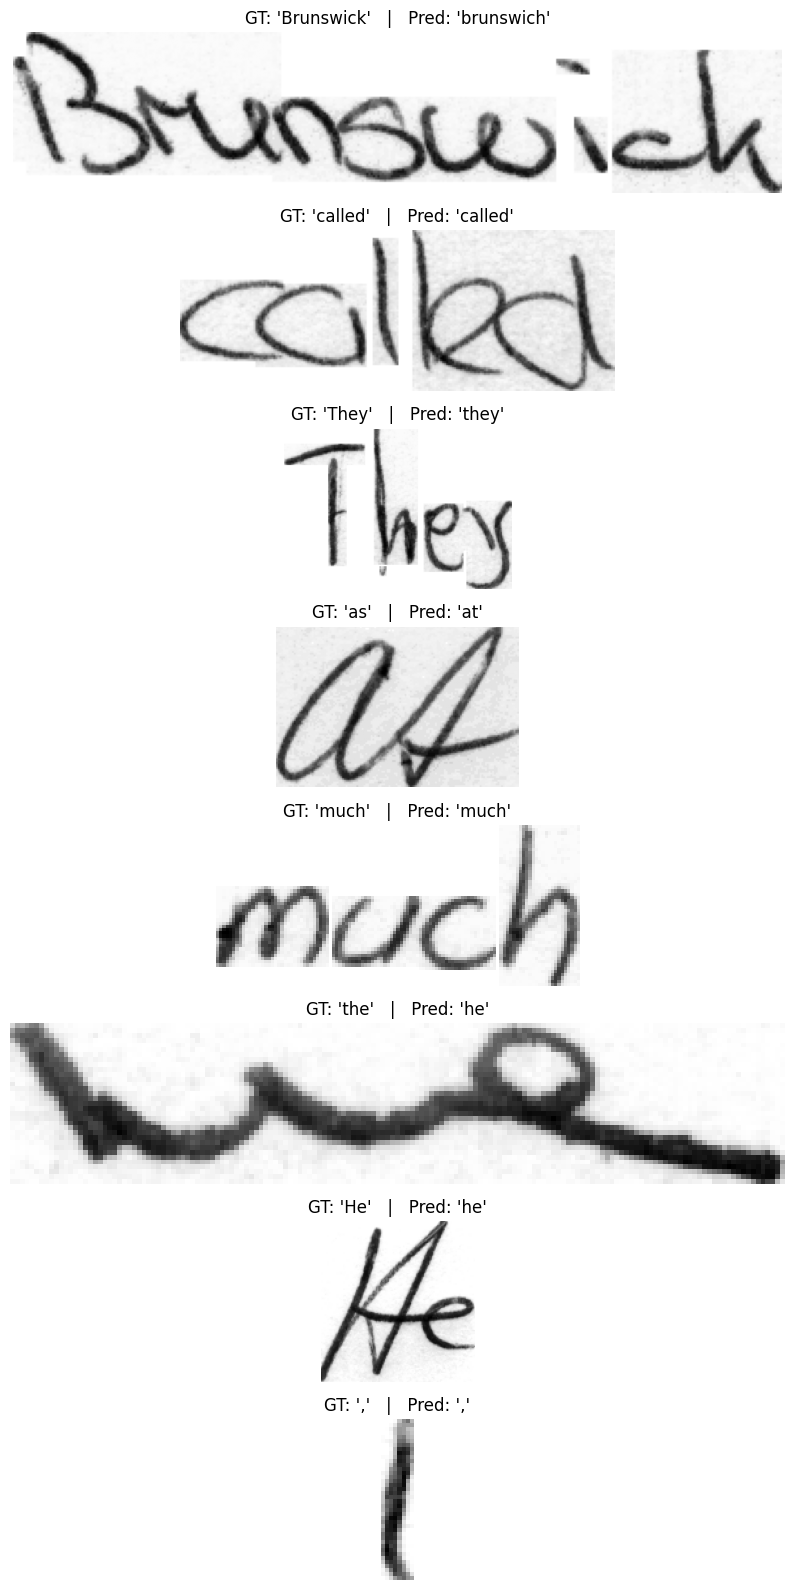

In [6]:
import numpy as np, matplotlib.pyplot as plt
from src.inference import predict
from src.dataset import load_iam_splits

_, _, test_hf = load_iam_splits()
idxs = np.random.choice(len(test_hf), 8, replace=False)
fig, axes = plt.subplots(8, 1, figsize=(12, 16))
for ax, i in zip(axes, idxs):
    s = test_hf[int(i)]
    pred = predict(m3, s['image'], encoder, device)
    ax.imshow(s['image'], cmap='gray')
    ax.set_title(f"GT: '{s['text']}'   |   Pred: '{pred}'")
    ax.axis('off')
plt.tight_layout(); plt.show()

## 6. Final Results Across Milestones

In [7]:
print('=== Final Results Across All Milestones ===')
print(f'{"Model":<26}{"Val CER":>10}{"Val WER":>10}{"Test CER":>10}{"Test WER":>10}')
print('-' * 66)
print(f'{"M1 baseline CRNN":<26}{0.1065:>10.4f}{0.2460:>10.4f}{"—":>10}{"—":>10}')
print(f'{"M2 STN-CRNN + aug":<26}{0.0867:>10.4f}{0.2012:>10.4f}{m2_test["mean_cer"]:>10.4f}{m2_test["mean_wer"]:>10.4f}')
print(f'{"M3 fine-tuned":<26}{m3_val_cer:>10.4f}{m3_val_wer:>10.4f}{m3_test["mean_cer"]:>10.4f}{m3_test["mean_wer"]:>10.4f}')

=== Final Results Across All Milestones ===
Model                        Val CER   Val WER  Test CER  Test WER
------------------------------------------------------------------
M1 baseline CRNN              0.1065    0.2460         —         —
M2 STN-CRNN + aug             0.0867    0.2012    0.0981    0.2234
M3 fine-tuned                 0.0903    0.2099    0.0969    0.2215
